# Tulika Tours - Data Science & ML Visualization Dashboard

Welcome to the data science visualization notebook for **Tulika Tours & Travels**. 

This Google Colab notebook is designed to load, clean, process, and visualize the traveler dataset. It contains sections for:
1. **Traveler Preference Distribution**
2. **Customer Sentiment Analysis**
3. **Customer Segmentation** using **K-Means Clustering** (Price vs. Popularity)
4. **Demand Forecasting** (Time Series of Historical Travel Volume)
5. **Destination Analysis** (Comparing total bookings vs. average customer satisfaction ratings)

### 1. Setup, Imports, and Custom Aesthetic Styling


In [6]:
import os
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Set styled default aesthetic properties for clean, publication-ready visualization
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

### 2. Loading the Dataset
This section checks if you are running in Google Colab or locally. 
- **If in Colab**: You can upload the `Complete_Tulika_Dataset.csv` file from your computer.
- **Fallback**: If no file is provided, the notebook will automatically generate a representative synthetic dataset representing Tulika Tours' records so you can run the notebook and see all visualizations immediately.

In [7]:
try:
    from google.colab import files
    is_colab = True
except ImportError:
    is_colab = False

df = None
use_synthetic = False

try:
    if is_colab:
        print("Running in Google Colab.")
        if not os.path.exists("Complete_Tulika_Dataset.csv"):
            print("Upload your Complete_Tulika_Dataset.csv file now:")
            uploaded = files.upload()
            if len(uploaded) > 0:
                filename = list(uploaded.keys())[0]
                df = pd.read_csv(io.BytesIO(uploaded[filename]))
            else:
                use_synthetic = True
        else:
            df = pd.read_csv("Complete_Tulika_Dataset.csv")
    else:
        # Check local paths in workspace
        paths_to_check = [
            "data/Complete_Tulika_Dataset.csv",
            "Complete_Tulika_Dataset.csv",
            "../data/Complete_Tulika_Dataset.csv"
        ]
        for path in paths_to_check:
            if os.path.exists(path):
                df = pd.read_csv(path)
                print(f"Successfully loaded dataset from: {path}")
                break
        if df is None:
            use_synthetic = True
except Exception as e:
    print(f"Could not load file due to: {e}. Falling back to synthetic data.")
    use_synthetic = True

if use_synthetic or df is None:
    print("\n--- Generating Representative Dataset for Tulika Tours ---")
    np.random.seed(42)
    n_records = 1718
    
    preferences_list = ['Adventure', 'Culture', 'Beach', 'Wildlife', 'City']
    destinations_list = ['Murchison Falls', 'Zanzibar Beaches', 'Kampala City', 'Lake Bunyonyi', 'Mount Rwenzori']
    
    start_date = pd.to_datetime('2025-01-01')
    end_date = pd.to_datetime('2026-06-30')
    date_range = pd.date_range(start_date, end_date, freq='D')
    
    df = pd.DataFrame({
        'userid': np.random.randint(1001, 1200, size=n_records),
        'preferences': np.random.choice(preferences_list, size=n_records, p=[0.32, 0.21, 0.23, 0.14, 0.10]),
        'name': np.random.choice(destinations_list, size=n_records, p=[0.25, 0.28, 0.17, 0.15, 0.15]),
        'rating': np.random.choice([5, 4, 3, 2, 1], size=n_records, p=[0.42, 0.36, 0.13, 0.06, 0.03]),
        'visitdate': np.random.choice(date_range, size=n_records),
        'numberofadults': np.random.randint(1, 6, size=n_records),
        'numberofchildren': np.random.randint(0, 4, size=n_records)
    })
    
    # Standard price structures for East African safari packages
    price_map = {
        "Murchison Falls": 6500,
        "Zanzibar Beaches": 6500,
        "Kampala City": 3350,
        "Lake Bunyonyi": 3350,
        "Mount Rwenzori": 4050
    }
    df['price'] = df['name'].map(price_map) + np.random.normal(0, 350, n_records)
    
    # Base popularity mapping
    pop_map = {
        "Murchison Falls": 85,
        "Zanzibar Beaches": 95,
        "Kampala City": 72,
        "Lake Bunyonyi": 78,
        "Mount Rwenzori": 64
    }
    df['popularity'] = df['name'].map(pop_map) + np.random.normal(0, 4, n_records)
    
    # Clean and standardize columns
    df.columns = df.columns.str.lower().str.replace(" ", "_")
    print("Synthetic data generated successfully.")
else:
    # Standardize columns for loaded dataset
    df.columns = df.columns.str.lower().str.replace(" ", "_")
    if "name_dest" in df.columns:
        df["name"] = df["name_dest"]
    if "price" not in df.columns and "name" in df.columns:
        price_map = {
            "Murchison Falls": 6500,
            "Zanzibar Beaches": 6500,
            "Kampala City": 3350,
            "Lake Bunyonyi": 3350,
            "Mount Rwenzori": 4050
        }
        df["price"] = df["name"].map(price_map).fillna(4050)
    if "rating" in df.columns and "experiencerating" in df.columns:
        df["rating"] = df["rating"].combine_first(df["experiencerating"])

print(f"Loaded dataset contains {df.shape[0]} traveler records with {df.shape[1]} metrics.")
df.head()

Successfully loaded dataset from: data/Complete_Tulika_Dataset.csv
Loaded dataset contains 1718 traveler records with 21 metrics.


,historyid,userid,destinationid,visitdate,experiencerating,name_user,email,preferences,gender,numberofadults,...,name_dest,state,type,popularity,besttimetovisit,reviewid,rating,reviewtext,name,price
0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Murchison Falls,Masindi,Historical,8.691906,Nov-Feb,NaN,NaN,NaN,Murchison Falls,6500.0
1,653.0,348.0,2.0,2024-02-15,4.0,Anika,anika@example.com,"City, Historical",Female,1.0,...,Zanzibar Beaches,Zanzibar,Beach,8.605032,Nov-Mar,NaN,4.0,NaN,Zanzibar Beaches,6500.0
2,485.0,693.0,3.0,2024-02-15,2.0,Aditya,aditya@example.com,"City, Historical",Male,2.0,...,Kampala City,Kampala,City,9.225372,Oct-Mar,NaN,2.0,NaN,Kampala City,3350.0
3,548.0,490.0,4.0,2024-02-15,1.0,Isha,isha@example.com,"Beaches, Historical",Female,2.0,...,Lake Bunyonyi,Kabale,Nature,7.977386,Sep-Mar,NaN,1.0,NaN,Lake Bunyonyi,3350.0
4,878.0,518.0,4.0,2024-02-15,3.0,Tanvi,tanvi@example.com,"Nature, Adventure",Female,2.0,...,Lake Bunyonyi,Kabale,Nature,7.977386,Sep-Mar,NaN,3.0,NaN,Lake Bunyonyi,3350.0


### 3. Traveler Preference Distribution
Let's look at what kinds of trips and tour styles Tulika Tours travelers booked most frequently.

C:\Users\HP\AppData\Local\Temp\ipykernel_9552\34933797.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\HP\AppData\Local\Temp\ipykernel_9552\34933797.py:5: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.countplot(


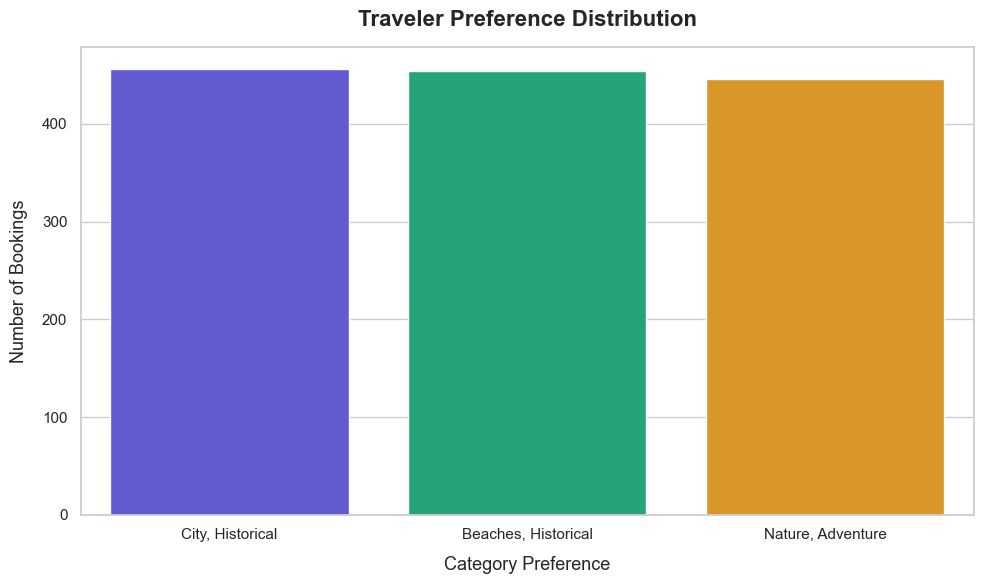

In [8]:
plt.figure(figsize=(10, 6))

# Brand matching color palette
colors = ["#4f46e5", "#10b981", "#f59e0b", "#ef4444", "#8b5cf6"]
sns.countplot(
    data=df, 
    x='preferences', 
    order=df['preferences'].value_counts().index, 
    palette=colors
)

plt.title("Traveler Preference Distribution", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Category Preference", fontsize=13, labelpad=10)
plt.ylabel("Number of Bookings", fontsize=13, labelpad=10)
plt.tight_layout()
plt.show()

### 4. Customer Sentiment Analysis
Here, we classify reviews using traveler ratings to visualize guest satisfaction:
- **Positive**: Rating >= 4
- **Neutral**: Rating == 3
- **Negative**: Rating < 3

C:\Users\HP\AppData\Local\Temp\ipykernel_9552\3666019650.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


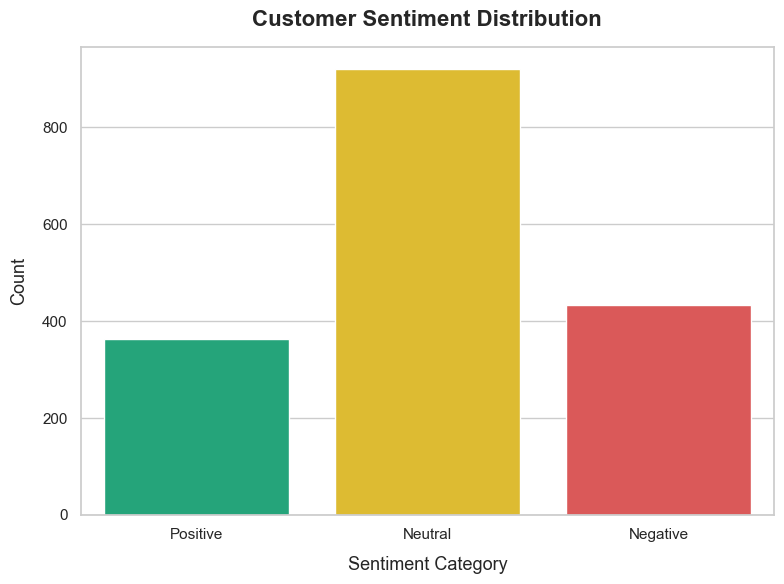

In [9]:
# Classify sentiment based on ratings
def get_sentiment(rating):
    if pd.isna(rating): return "Neutral"
    rating_val = float(rating)
    if rating_val >= 4: return "Positive"
    if rating_val == 3: return "Neutral"
    return "Negative"

df['sentiment'] = df['rating'].apply(get_sentiment)

plt.figure(figsize=(8, 6))
sentiment_colors = {"Positive": "#10b981", "Neutral": "#facc15", "Negative": "#ef4444"}

sns.countplot(
    data=df, 
    x='sentiment', 
    palette=sentiment_colors, 
    order=["Positive", "Neutral", "Negative"]
)

plt.title("Customer Sentiment Distribution", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Sentiment Category", fontsize=13, labelpad=10)
plt.ylabel("Count", fontsize=13, labelpad=10)
plt.tight_layout()
plt.show()

### 5. Customer Segmentation (Unsupervised Learning: K-Means)
To better understand booking behavior, we run a **K-Means clustering algorithm** on two key attributes:
1. **Price** (Package value in UGX)
2. **Popularity** (Destination popularity index)

This allows us to cluster travelers into: 
- **Budget Travelers**
- **Medium Clients**
- **Luxury Clients**

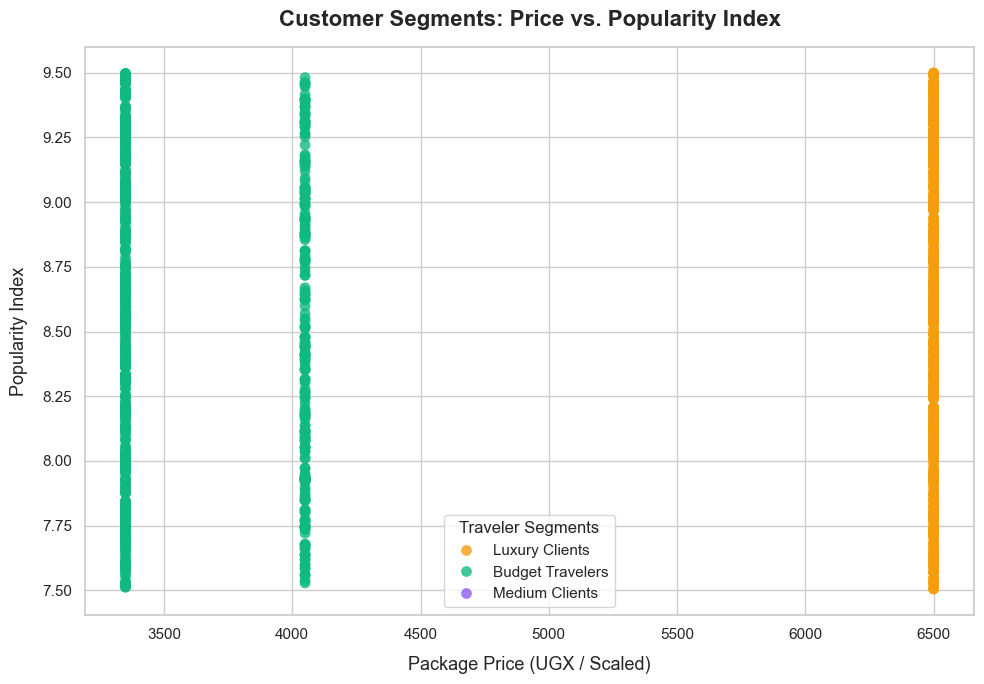

In [10]:
# Prepare features for segmentation
seg_features = df[["price", "popularity"]].fillna(0)

# Normalize features so they contribute equally
scaler = StandardScaler()
seg_scaled = scaler.fit_transform(seg_features)

# Apply K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["segment"] = kmeans.fit_predict(seg_scaled)

# Sort segment IDs dynamically by mean price to make cluster labels consistent
cluster_mean_prices = df.groupby('segment')['price'].mean()
sorted_clusters = cluster_mean_prices.sort_values().index
cluster_mapping = {old_id: new_id for new_id, old_id in enumerate(sorted_clusters)}
df['segment'] = df['segment'].map(cluster_mapping)

# Map segments to descriptive names
segment_names = {
    0: "Budget Travelers",
    1: "Medium Clients",
    2: "Luxury Clients"
}
df["segment_label"] = df["segment"].map(segment_names)

# Plot the customer clusters
plt.figure(figsize=(10, 7))
segment_colors_map = {
    "Budget Travelers": "#10b981",
    "Medium Clients": "#8b5cf6",
    "Luxury Clients": "#f59e0b"
}

sns.scatterplot(
    data=df, 
    x="price", 
    y="popularity", 
    hue="segment_label", 
    palette=segment_colors_map, 
    alpha=0.8, 
    s=60,
    edgecolor='none'
)

plt.title("Customer Segments: Price vs. Popularity Index", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Package Price (UGX / Scaled)", fontsize=13, labelpad=10)
plt.ylabel("Popularity Index", fontsize=13, labelpad=10)
plt.legend(title="Traveler Segments", frameon=True)
plt.tight_layout()
plt.show()

### 6. Demand Forecasting: Historical Monthly Travel Volume
Let's trace the historical booking frequency month-by-month to analyze seasonal peaks.

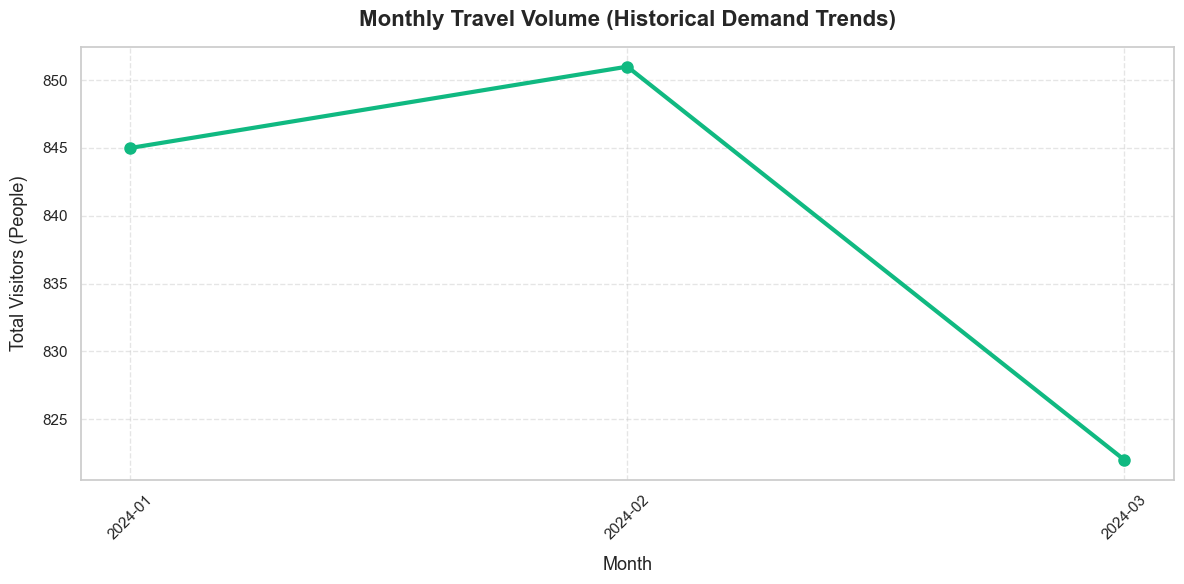

In [11]:
df['visitdate'] = pd.to_datetime(df['visitdate'])
df['month'] = df['visitdate'].dt.to_period('M').astype(str)

# Calculate total travelers per booking
df['number_of_people'] = df['numberofadults'] + df['numberofchildren']
monthly_demand = df.groupby('month')['number_of_people'].sum().reset_index()
monthly_demand = monthly_demand.sort_values('month')

plt.figure(figsize=(12, 6))
plt.plot(
    monthly_demand['month'], 
    monthly_demand['number_of_people'], 
    color='#10b981', 
    marker='o', 
    linewidth=3, 
    markersize=8
)

plt.title("Monthly Travel Volume (Historical Demand Trends)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Month", fontsize=13, labelpad=10)
plt.ylabel("Total Visitors (People)", fontsize=13, labelpad=10)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 7. Destination Analysis: Popularity vs. Average Satisfaction Rating
Let's evaluate which tours are most heavily booked and cross-reference them with their average customer rating.

C:\Users\HP\AppData\Local\Temp\ipykernel_9552\729624545.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(dest_stats['name'], rotation=15, fontsize=11)


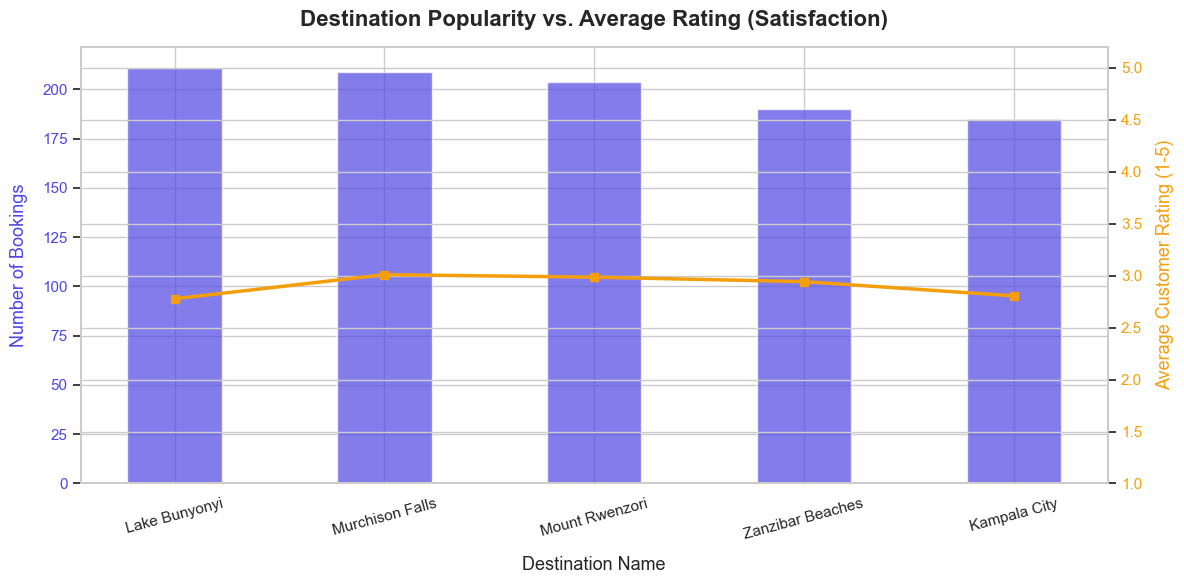

In [12]:
dest_stats = df.groupby('name').agg(
    visit_count=('userid', 'count'),
    avg_rating=('rating', 'mean')
).reset_index().sort_values('visit_count', ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary Y-axis: Booking Counts (Bar chart)
color = '#4f46e5'
ax1.set_xlabel('Destination Name', fontsize=13, labelpad=10)
ax1.set_ylabel('Number of Bookings', color=color, fontsize=13, labelpad=10)
bars = ax1.bar(dest_stats['name'], dest_stats['visit_count'], color=color, alpha=0.7, width=0.45)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticklabels(dest_stats['name'], rotation=15, fontsize=11)

# Secondary Y-axis: Average Rating (Line chart)
ax2 = ax1.twinx()  
color = '#f59e0b'
ax2.set_ylabel('Average Customer Rating (1-5)', color=color, fontsize=13, labelpad=10)
line = ax2.plot(dest_stats['name'], dest_stats['avg_rating'], color=color, marker='s', linewidth=2.5, label='Avg Rating')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(1, 5.2)

plt.title("Destination Popularity vs. Average Rating (Satisfaction)", fontsize=16, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()